In [104]:
import numpy as np
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Import Dataset

In [106]:
df = pd.read_csv(r"C:/Users/bda/Desktop/APS/Telco_Churn/dataset/telcochurn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [107]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Column Split

In [110]:
x = df.iloc[:, 1:-1] #no need customer id col, and last column is for y
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [111]:
y = df.iloc[:,-1] #only last column aka if they churn or not
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str

# Train-Test Split

In [112]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [113]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2920,Female,0,Yes,No,72,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Mailed check,85.10,6155.40
2966,Female,1,No,No,14,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,46.35,672.70
6099,Female,0,Yes,Yes,71,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.70,1810.55
5482,Male,0,Yes,Yes,33,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,73.90,2405.05
2012,Female,0,Yes,No,47,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,98.75,4533.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931,Male,0,Yes,No,15,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.45,1539.80
3264,Female,0,No,Yes,10,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,No,Month-to-month,Yes,Electronic check,91.10,964.35
1653,Male,0,Yes,No,58,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.75,1185.95
2607,Male,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.75,69.75


In [114]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2200,Female,0,No,No,19,Yes,No,DSL,No,Yes,No,No,Yes,No,One year,No,Electronic check,58.20,1045.25
4627,Male,0,No,No,60,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),116.60,7049.50
3225,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,71.95,923.85
2828,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.45,20.45
3768,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),77.75,4266.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45
5333,Female,0,Yes,Yes,13,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,88.35,1222.80
6972,Female,1,No,No,56,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,111.95,6418.90
4598,Male,0,No,No,18,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,56.25,969.85


In [115]:
y_train

2920     No
2966     No
6099     No
5482    Yes
2012    Yes
       ... 
4931     No
3264     No
1653     No
2607    Yes
2732     No
Name: Churn, Length: 5634, dtype: str

In [116]:
y_test

2200     No
4627     No
3225     No
2828     No
3768     No
       ... 
2631    Yes
5333    Yes
6972    Yes
4598     No
3065     No
Name: Churn, Length: 1409, dtype: str

# Preprocessing

In [117]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges'] # we can apply SC for numeric
categorical_features = [col for col in x_train.columns if col not in numeric_features] # for categorical we have to encode first so we apply 1 hot encoding

In [118]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder # OneHotEncoder handles the text columns, StandardScaler handles the numeric columns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [119]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [120]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [121]:
# use label encoding for y aka DEPENDENT VARIABLE
le = LabelEncoder()
y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

In [122]:
classifier = LogisticRegression(random_state=0)
classifier.fit(x_train_processed, y_train_processed)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [123]:
y_pred = classifier.predict(x_test_processed)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [124]:
cm = confusion_matrix(y_test_processed, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[931 110]
 [175 193]]


In [125]:
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1041
           1       0.64      0.52      0.58       368

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



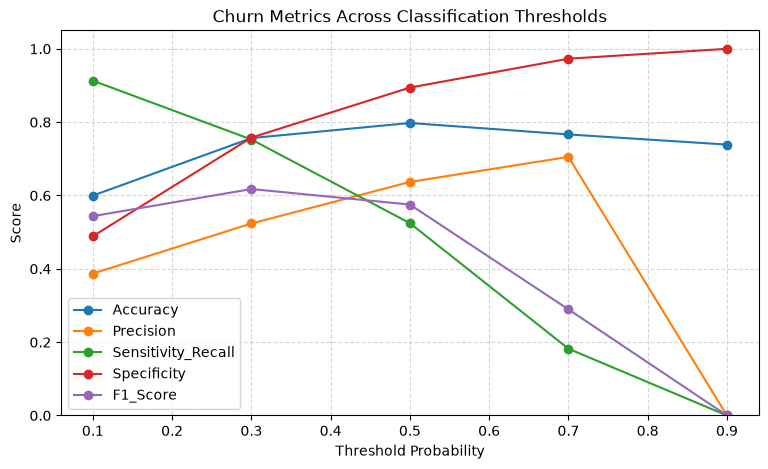

In [136]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Get predicted probabilities for Churn (Class 1 is 'Yes/Churn')
# index 1 gives the probability that a customer WILL churn
churn_probabilities = classifier.predict_proba(x_test_processed)[:, 1]

# 2. Define actual target values from your test set
actual_churn = y_test_processed 

# 3. Create the loop for multiple thresholds
metrics_data = []
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9] # Added more points for a smoother graph!

for threshold in thresholds:
    # If probability is >= threshold, predict they will Churn (1)
    predicted_churn = (churn_probabilities >= threshold).astype(int)

    # Calculate Confusion Matrix elements
    cm = confusion_matrix(actual_churn, predicted_churn)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) 

    # Calculate all metrics
    accuracy = accuracy_score(actual_churn, predicted_churn)
    precision = precision_score(actual_churn, predicted_churn, zero_division=0)
    recall = recall_score(actual_churn, predicted_churn, zero_division=0)
    f1 = f1_score(actual_churn, predicted_churn, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Append to list
    metrics_data.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity_Recall': recall,
        'Specificity': specificity,
        'F1_Score': f1
    })

# 4. Convert to DataFrame
threshold_metrics = pd.DataFrame(metrics_data)

# 5. Plot the graph
threshold_metrics.plot(
    x="Threshold",
    y=["Accuracy", "Precision", "Sensitivity_Recall", "Specificity", "F1_Score"],
    marker="o",
    figsize=(9, 5)
)

plt.title("Churn Metrics Across Classification Thresholds")
plt.ylabel("Score")
plt.xlabel("Threshold Probability")
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Synthetically create imbalanced data

In [126]:
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from collections import Counter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:
print("Before SMOTE:", Counter(y_train_processed))

Before SMOTE: Counter({np.int64(0): 4133, np.int64(1): 1501})


In [128]:
target_churn = int(Counter(y_train_processed)[1] * 1.05)

In [129]:
smote = SMOTE(sampling_strategy={0: Counter(y_train_processed)[0], 1: target_churn}, random_state=0) #initialise smote with churn aka 1 as 5% more

In [130]:
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_processed, y_train_processed) #use only processed training dataset and create resampled

In [131]:
print("After SMOTE:", Counter(y_train_resampled))

After SMOTE: Counter({np.int64(0): 4133, np.int64(1): 1576})


In [139]:
x_train_processed

array([[ 1.61253221,  0.67415397,  1.70492806, ...,  0.        ,
         0.        ,  1.        ],
       [-0.7479074 , -0.61489382, -0.71107895, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.57183498, -1.3350973 , -0.20967388, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.04277093, -1.46649701, -0.48491016, ...,  0.        ,
         0.        ,  1.        ],
       [-1.27697145,  0.16352472, -0.97677494, ...,  0.        ,
         1.        ,  0.        ],
       [-1.15487975, -1.47814002, -0.9658686 , ...,  1.        ,
         0.        ,  0.        ]], shape=(5634, 30))

In [140]:
x_train_resampled

array([[ 1.61253221,  0.67415397,  1.70492806, ...,  0.        ,
         0.        ,  1.        ],
       [-0.7479074 , -0.61489382, -0.71107895, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.57183498, -1.3350973 , -0.20967388, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.26748996,  0.5368284 , -0.96119912, ...,  0.        ,
         1.        ,  0.        ],
       [-0.94421622,  1.18329773, -0.59286855, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.03063323,  1.28638982,  1.60286908, ...,  0.        ,
         1.        ,  0.        ]], shape=(5709, 30))

In [138]:
y_train_processed

array([0, 0, 0, ..., 0, 1, 0], shape=(5634,))

In [137]:
y_train_resampled

array([0, 0, 0, ..., 1, 1, 1], shape=(5709,))

In [141]:
classifier = LogisticRegression(random_state=0, max_iter=1000)

# Fit the model on imbalanced dataset
classifier.fit(x_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [142]:
y_pred_train = classifier.predict(x_train_resampled)
cm = confusion_matrix(y_train_resampled, y_pred_train)
cm

array([[3676,  457],
       [ 658,  918]])

In [143]:
# Generate the classification report using your training predictions
report_text = classification_report(y_train_resampled, y_pred_train, target_names=['No Churn', 'Churn'])

print("Classification Report (Resampled Training Data):")
print(report_text)

Classification Report (Resampled Training Data):
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      4133
       Churn       0.67      0.58      0.62      1576

    accuracy                           0.80      5709
   macro avg       0.76      0.74      0.75      5709
weighted avg       0.80      0.80      0.80      5709



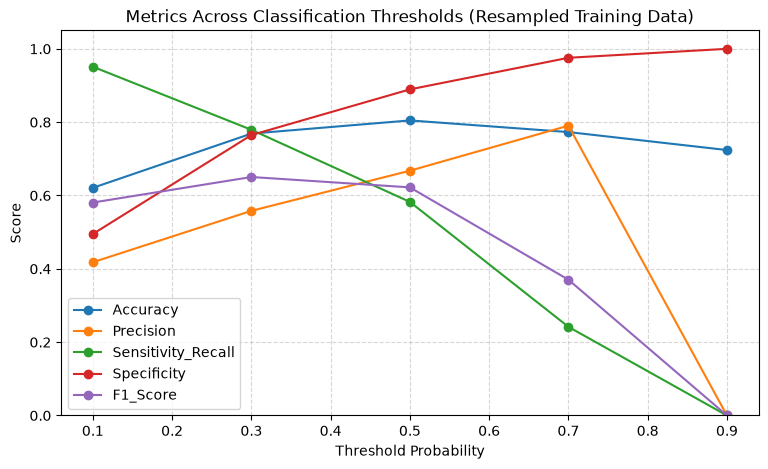

In [144]:
churn_probabilities = classifier.predict_proba(x_train_resampled)[:, 1] # 1 is churn so calc prob of gtting class 1
actual_churn = y_train_resampled #train data has 'actual' churn values

metrics_data = []
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9] # for these thresholds

for threshold in thresholds:
    predicted_churn = (churn_probabilities >= threshold).astype(int) #if pred > threshold then its churn

    cm = confusion_matrix(actual_churn, predicted_churn)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0) 

    accuracy = accuracy_score(actual_churn, predicted_churn)
    precision = precision_score(actual_churn, predicted_churn, zero_division=0)
    recall = recall_score(actual_churn, predicted_churn, zero_division=0)
    f1 = f1_score(actual_churn, predicted_churn, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics_data.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity_Recall': recall,
        'Specificity': specificity,
        'F1_Score': f1
    })

threshold_metrics = pd.DataFrame(metrics_data)

threshold_metrics.plot(
    x="Threshold",
    y=["Accuracy", "Precision", "Sensitivity_Recall", "Specificity", "F1_Score"],
    marker="o",
    figsize=(9, 5)
)

plt.title("Metrics Across Classification Thresholds (Resampled Training Data)")
plt.ylabel("Score")
plt.xlabel("Threshold Probability")
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()